<a href="https://colab.research.google.com/github/vishal7379/Colab/blob/main/LPV_practicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-92_l7l0r
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-92_l7l0r
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 28f872a2f99a1b201bcd0db14fdbc5a496b9bfd7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=10741 sha256=90a829d54142cdbaf5703d6409de30ec0002408286cfbcd108dfdd84cf0ee4fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-7n9jhcz4/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter


In [ ]:
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpo_yvo_31".


HPC_4_add_vector

In [ ]:
%%cuda
#include <iostream>
#include <cstdlib>
#include <chrono>
#include <cuda.h>

#define BLOCK_SIZE 256
using namespace std;

// Fill array with random values
void fill_array(int *arr, int size){
    for(int i = 0; i < size; i++){
        arr[i] = rand() % 100;
    }
}

// CPU addition
void add_cpu(int *a, int *b, int *c, int size){
    for(int i = 0; i < size; i++){
        c[i] = a[i] + b[i];
    }
}

// Print first few elements (avoid huge output)
void print_array(int *arr, int size){
    int limit = min(size, 10);
    for(int i = 0; i < limit; i++){
        cout << arr[i] << " ";
    }
    cout << endl;
}

// CUDA kernel
__global__ void add(int *a, int *b, int *c, int size){
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if(i < size){
        c[i] = a[i] + b[i];
    }
}

int main(){
    int size = 1000000;
    cout << "Vector size: " << size << endl;
    // Allocate CPU memory
    int *a = new int[size];
    int *b = new int[size];
    int *c_cpu = new int[size];
    int *c_gpu = new int[size];

    fill_array(a, size);
    fill_array(b, size);

    cout << "Array A (first 10): ";
    print_array(a, size);
    cout << "Array B (first 10): ";
    print_array(b, size);

    // Allocate GPU memory
    int *d_a, *d_b, *d_c;
    cudaMalloc(&d_a, size * sizeof(int));
    cudaMalloc(&d_b, size * sizeof(int));
    cudaMalloc(&d_c, size * sizeof(int));

    // Copy to GPU
    cudaMemcpy(d_a, a, size * sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, b, size * sizeof(int), cudaMemcpyHostToDevice);

    // Grid & block config (CORRECTED)
    dim3 block(BLOCK_SIZE);
    dim3 grid((size + BLOCK_SIZE - 1) / BLOCK_SIZE);

    // GPU timing
    cudaEvent_t start, stop;
    float gpu_time;

    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    add<<<grid, block>>>(d_a, d_b, d_c, size);

    cudaDeviceSynchronize();  // IMPORTANT

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    cudaEventElapsedTime(&gpu_time, start, stop);

    // Copy result back
    cudaMemcpy(c_gpu, d_c, size * sizeof(int), cudaMemcpyDeviceToHost);

    cout << "GPU Result (first 10): ";
    print_array(c_gpu, size);
    cout << "GPU Time: " << gpu_time << " ms\n";

    // CPU timing (CORRECT METHOD)
    auto start_cpu = chrono::high_resolution_clock::now();

    add_cpu(a, b, c_cpu, size);

    auto end_cpu = chrono::high_resolution_clock::now();

    double cpu_time = chrono::duration<double, milli>(end_cpu - start_cpu).count();

    cout << "CPU Result (first 10): ";
    print_array(c_cpu, size);
    cout << "CPU Time: " << cpu_time << " ms\n";

    // Free memory
    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);

    delete[] a;
    delete[] b;
    delete[] c_cpu;
    delete[] c_gpu;

    return 0;
}

Vector size: 1000000
Array A (first 10): 83 86 77 15 93 35 86 92 49 21 
Array B (first 10): 89 63 84 93 81 55 6 93 61 50 
GPU Result (first 10): 172 149 161 108 174 90 92 185 110 71 
GPU Time: 0.158432 ms
CPU Result (first 10): 172 149 161 108 174 90 92 185 110 71 
CPU Time: 4.62835 ms



HPC_4_multiply_matrix

In [ ]:
%%cuda
#include <iostream>
#include <cstdlib>
#include <chrono>
#include <cuda.h>

#define BLOCK_SIZE 16
using namespace std;

// Initialize matrix
void initialize_matrix(int *mat, int rows, int cols){
    for(int i = 0; i < rows; i++){
        for(int j = 0; j < cols; j++){
            mat[i*cols + j] = rand() % 10;
        }
    }
}

// Print first few elements only
void print_matrix(int *mat, int rows, int cols){
    int r = min(rows, 5);
    int c = min(cols, 5);
    for(int i = 0; i < r; i++){
        for(int j = 0; j < c; j++){
            cout << mat[i*cols + j] << " ";
        }
        cout << endl;
    }
    cout << endl;
}

// CPU multiplication
void matrix_multiplication_cpu(int *A, int *B, int *C, int common, int rows, int cols){
    for(int i = 0; i < rows; i++){
        for(int j = 0; j < cols; j++){
            int sum = 0;
            for(int k = 0; k < common; k++){
                sum += A[i*common + k] * B[k*cols + j];
            }
            C[i*cols + j] = sum;
        }
    }
}

// CUDA kernel
__global__ void matrix_multiply(int *A, int *B, int *C, int rows, int common, int cols){
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if(row < rows && col < cols){
        int sum = 0;
        for(int k = 0; k < common; k++){
            sum += A[row*common + k] * B[k*cols + col];
        }
        C[row*cols + col] = sum;
    }
}

int main(){

    // ❌ cin removed (Colab issue)
    int A_rows = 512, A_cols = 512;
    int B_rows = A_cols, B_cols = 512;

    int C_rows = A_rows;
    int C_cols = B_cols;

    cout << "Matrix size: " << A_rows << "x" << A_cols << endl;

    int A_size = A_rows * A_cols;
    int B_size = B_rows * B_cols;
    int C_size = C_rows * C_cols;

    int *A = new int[A_size];
    int *B = new int[B_size];
    int *C_cpu = new int[C_size];
    int *C_gpu = new int[C_size];

    initialize_matrix(A, A_rows, A_cols);
    initialize_matrix(B, B_rows, B_cols);

    cout << "Matrix A (first 5x5):\n";
    print_matrix(A, A_rows, A_cols);

    cout << "Matrix B (first 5x5):\n";
    print_matrix(B, B_rows, B_cols);

    // GPU memory
    int *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, A_size * sizeof(int));
    cudaMalloc(&d_B, B_size * sizeof(int));
    cudaMalloc(&d_C, C_size * sizeof(int));

    cudaMemcpy(d_A, A, A_size * sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, B, B_size * sizeof(int), cudaMemcpyHostToDevice);

    // ✅ Correct grid calculation
    dim3 block(BLOCK_SIZE, BLOCK_SIZE);
    dim3 grid((C_cols + BLOCK_SIZE - 1) / BLOCK_SIZE,
              (C_rows + BLOCK_SIZE - 1) / BLOCK_SIZE);

    // GPU timing
    cudaEvent_t start, stop;
    float gpu_time;

    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    matrix_multiply<<<grid, block>>>(d_A, d_B, d_C, C_rows, A_cols, C_cols);

    cudaDeviceSynchronize();  // IMPORTANT

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&gpu_time, start, stop);

    cudaMemcpy(C_gpu, d_C, C_size * sizeof(int), cudaMemcpyDeviceToHost);

    cout << "GPU Result (first 5x5):\n";
    print_matrix(C_gpu, C_rows, C_cols);
    cout << "GPU Time: " << gpu_time << " ms\n";

    // CPU timing (correct way)
    auto start_cpu = chrono::high_resolution_clock::now();

    matrix_multiplication_cpu(A, B, C_cpu, A_cols, C_rows, C_cols);

    auto end_cpu = chrono::high_resolution_clock::now();

    double cpu_time = chrono::duration<double, milli>(end_cpu - start_cpu).count();

    cout << "CPU Result (first 5x5):\n";
    print_matrix(C_cpu, C_rows, C_cols);
    cout << "CPU Time: " << cpu_time << " ms\n";

    // Free memory
    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    delete[] A;
    delete[] B;
    delete[] C_cpu;
    delete[] C_gpu;

    return 0;
}

Matrix size: 512x512
Matrix A (first 5x5):
3 6 7 5 3 
7 4 0 6 4 
1 4 0 3 1 
5 7 0 7 8 
1 0 0 7 0 

Matrix B (first 5x5):
9 7 4 8 8 
0 4 0 3 1 
9 3 1 4 7 
6 8 7 1 0 
4 6 1 6 7 

GPU Result (first 5x5):
11057 10652 10663 10558 10841 
10651 10596 10164 10047 10311 
10817 10505 10400 10177 10244 
10208 9973 10062 10217 10029 
10798 10584 10337 10193 10286 

GPU Time: 20.5592 ms
CPU Result (first 5x5):
11057 10652 10663 10558 10841 
10651 10596 10164 10047 10311 
10817 10505 10400 10177 10244 
10208 9973 10062 10217 10029 
10798 10584 10337 10193 10286 

CPU Time: 709.737 ms



DL_1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Boston.csv')
df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CAT. MEDV,Unnamed: 15,Unnamed: 16
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0,NaN,NaN
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0,NaN,NaN
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1,NaN,NaN
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1,NaN,NaN
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1,NaN,NaN
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7,0,NaN,NaN
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9,0,NaN,NaN
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1,0,NaN,NaN
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5,0,NaN,NaN
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9,0,NaN,NaN


In [ ]:
df.drop(columns=['Unnamed: 15','Unnamed: 16'],inplace=True)

In [ ]:
df.drop(columns=['CAT. MEDV'],inplace=True)

In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.corr()['MEDV'].sort_values()

,MEDV
LSTAT,-0.737663
PTRATIO,-0.507787
INDUS,-0.483725
TAX,-0.468536
NOX,-0.427321
CRIM,-0.388305
RAD,-0.381626
AGE,-0.376955
CHAS,0.175260
DIS,0.249929


In [ ]:
X = df.loc[:,['LSTAT','PTRATIO','RM']]
Y = df.loc[:,"MEDV"]
X.shape,Y.shape

((506, 3), (506,))

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.25,random_state=10)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(x_train)

StandardScaler()

In [ ]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(128,input_shape=(3,),activation='relu',name='input'))
model.add(Dense(64,activation='relu',name='layer_1'))
model.add(Dense(1,activation='linear',name='output'))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train,y_train,epochs=100,validation_split=0.05)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 532.6751 - mae: 21.3760 - val_loss: 695.7067 - val_mae: 23.5747
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 491.0381 - mae: 20.3825 - val_loss: 643.0721 - val_mae: 22.3531
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 435.9296 - mae: 18.9865 - val_loss: 568.8290 - val_mae: 20.5314
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 356.6381 - mae: 16.9162 - val_loss: 472.2917 - val_mae: 18.2643
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 259.1924 - mae: 14.1786 - val_loss: 358.4395 - val_mae: 15.2865
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 157.0630 - mae: 10.9036 - val_loss: 249.6692 - val_mae: 12.2515
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 77.4403 - mae: 7.4991 - val_loss: 170.9410 - val_mae: 10.0237
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 41.4518 - mae: 5.2137 - val_loss: 131.5188 - val_mae: 8.3238
Epoch 9/100
12/12 ━━

In [ ]:
output = model.evaluate(x_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 23.2578 - mae: 3.1721


In [ ]:
print(f"Mean Squared Error: {output[0]}"
      ,f"Mean Absolute Error: {output[1]}",sep="\n")

Mean Squared Error: 23.257776260375977
Mean Absolute Error: 3.1721229553222656


In [ ]:
y_pred = model.predict(x=x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [ ]:
print(*zip(y_pred,y_test))

(array([25.363173], dtype=float32), 28.4) (array([30.15173], dtype=float32), 31.1) (array([25.222427], dtype=float32), 23.5) (array([27.402395], dtype=float32), 26.6) (array([17.817345], dtype=float32), 19.6) (array([16.31097], dtype=float32), 14.3) (array([41.01839], dtype=float32), 50.0) (array([14.93982], dtype=float32), 14.3) (array([20.131927], dtype=float32), 20.7) (array([42.217953], dtype=float32), 37.6) (array([17.694832], dtype=float32), 20.4) (array([27.56017], dtype=float32), 27.5) (array([22.715302], dtype=float32), 36.2) (array([31.952778], dtype=float32), 32.0) (array([30.912428], dtype=float32), 33.1) (array([52.56233], dtype=float32), 48.8) (array([25.514992], dtype=float32), 24.6) (array([19.068106], dtype=float32), 26.4) (array([21.08222], dtype=float32), 23.2) (array([19.913445], dtype=float32), 17.0) (array([32.41227], dtype=float32), 41.3) (array([15.260931], dtype=float32), 14.9) (array([22.87611], dtype=float32), 18.5) (array([24.665321], dtype=float32), 25.0) (

DL_3

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

In [ ]:
train_df.shape

(60000, 785)

In [ ]:
test_df.shape

(10000, 785)

In [ ]:
train_df.describe()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


In [ ]:

train_df.label.unique()

array([2, 9, 6, 0, 3, 4, 5, 8, 7, 1])

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
x_train = train_df.iloc[:,1:].to_numpy()
x_train = x_train.reshape([-1,28,28,1])
x_train = x_train / 255

In [ ]:

y_train = train_df.iloc[:,0].to_numpy()

In [ ]:

x_test = test_df.iloc[:,1:].to_numpy()
x_test = x_test.reshape([-1,28,28,1])
x_test = x_test / 255

In [ ]:

y_test = test_df.iloc[:,0].to_numpy()

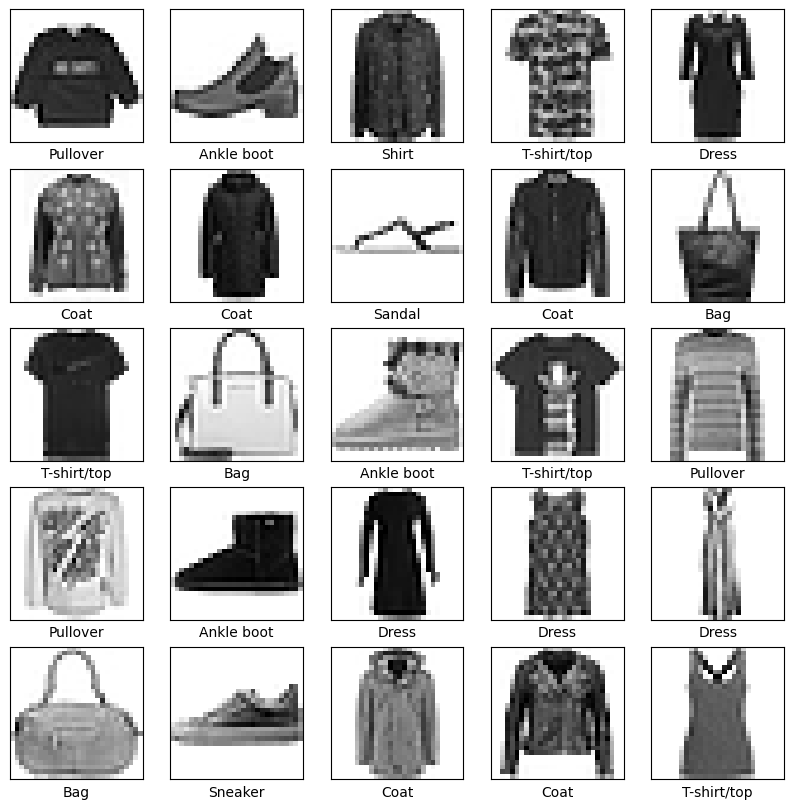

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout

In [ ]:
model = Sequential()

model.add(Conv2D(filters=64,kernel_size=(3,3),input_shape=(28,28,1),activation='relu'))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(rate=0.3))
model.add(Flatten())
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=10, activation='sigmoid'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │       346,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,114 (1.32 MB)

 Trainable params: 347,114 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train,y_train,epochs=50,batch_size=1200,validation_split=0.05)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.7204 - loss: 0.8607 - val_accuracy: 0.8087 - val_loss: 0.5184
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8406 - loss: 0.4596 - val_accuracy: 0.8557 - val_loss: 0.4303
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8606 - loss: 0.4018 - val_accuracy: 0.8613 - val_loss: 0.3937
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8708 - loss: 0.3735 - val_accuracy: 0.8753 - val_loss: 0.3638
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8784 - loss: 0.3496 - val_accuracy: 0.8803 - val_loss: 0.3460
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8849 - loss: 0.3312 - val_accuracy: 0.8810 - val_loss: 0.3378
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8894 - loss: 0.3191 - val_accuracy: 0.8857 - val_loss: 0.3260
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8927 - loss: 0.3068 - val_accuracy: 0.8873 - v

In [ ]:
evaluation = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9233 - loss: 0.2280


In [ ]:

print(f"Accuracy: {evaluation[1]}")

Accuracy: 0.92330002784729


In [ ]:

y_probas = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:

y_pred = y_probas.argmax(axis=-1)

In [ ]:

y_pred

array([0, 1, 2, ..., 8, 8, 1])

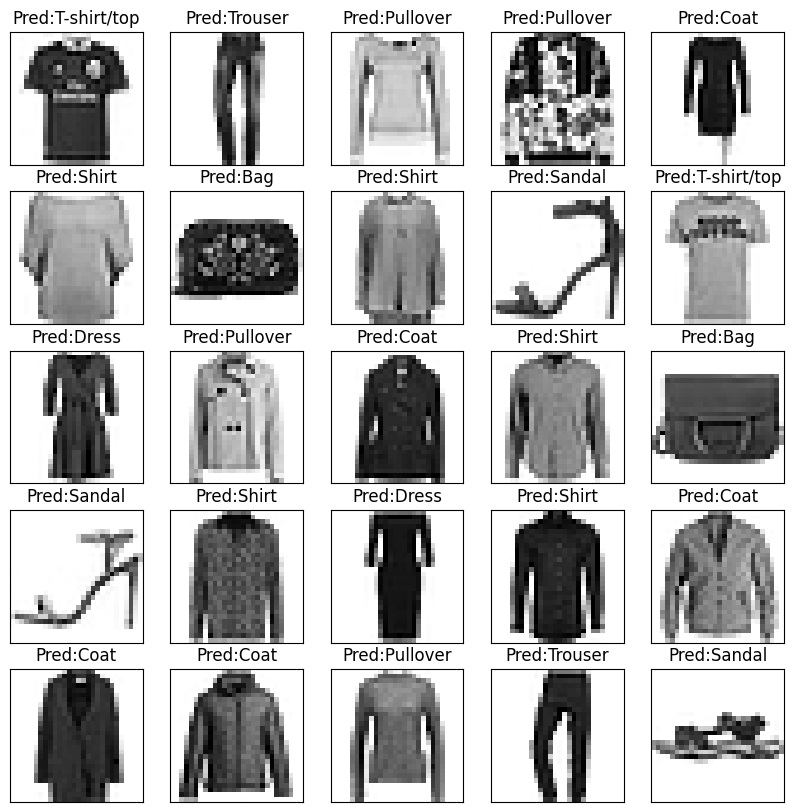

In [ ]:

plt.figure(figsize=(10,10),)
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
#     plt.xlabel(f"True Class:{y_test[i]}")
    plt.title(f"Pred:{class_names[y_pred[i]]}")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:

num_classes = 10
class_names = ["class {}".format(i) for i in range(num_classes)]
cr = classification_report(y_test, y_pred, target_names=class_names)
print(cr)

              precision    recall  f1-score   support

     class 0       0.86      0.89      0.88      1000
     class 1       0.99      0.99      0.99      1000
     class 2       0.91      0.84      0.88      1000
     class 3       0.91      0.94      0.93      1000
     class 4       0.87      0.92      0.89      1000
     class 5       0.99      0.97      0.98      1000
     class 6       0.80      0.77      0.78      1000
     class 7       0.95      0.98      0.96      1000
     class 8       0.98      0.98      0.98      1000
     class 9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



DL_4

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:

train_df = pd.read_csv('Google_Stock_Price_Train.csv')
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   object 
 5   Volume  1258 non-null   object 
dtypes: float64(3), object(3)
memory usage: 59.1+ KB


In [ ]:

test_df = pd.read_csv('Google_Stock_Price_Test.csv')
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    20 non-null     object 
 1   Open    20 non-null     float64
 2   High    20 non-null     float64
 3   Low     20 non-null     float64
 4   Close   20 non-null     float64
 5   Volume  20 non-null     object 
dtypes: float64(4), object(2)
memory usage: 1.1+ KB


In [ ]:

train = train_df.loc[:,["Open"]].values
train.shape

(1258, 1)

In [ ]:

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [ ]:

train_scaled = scaler.fit_transform(train)

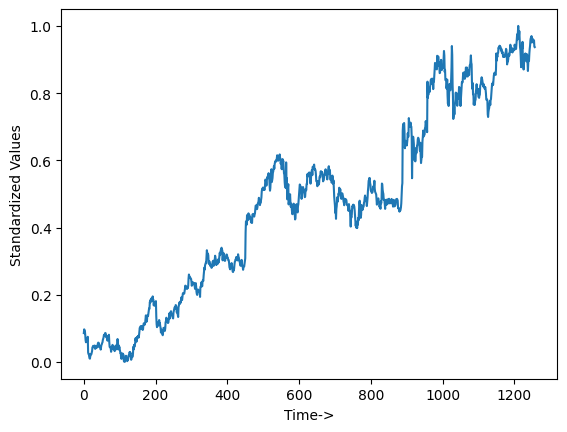

In [ ]:

plt.plot(train_scaled)
plt.ylabel("Standardized Values")
plt.xlabel("Time->")
plt.show()

In [ ]:

x_train = []
y_train = []
time = 60
for i in range(60,train_scaled.shape[0]):
    x_train.append(train_scaled[i-60:i,0])
    y_train.append(train_scaled[i,0])
x_train = np.array(x_train)
y_train = np.array(y_train)

In [ ]:

x_train.shape,y_train.shape

((1198, 60), (1198,))

In [ ]:

x_train = np.reshape(x_train,newshape=(x_train.shape[0],x_train.shape[1],1))
x_train.shape

(1198, 60, 1)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN,Dropout

In [ ]:

model = Sequential()

model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True, input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50,activation = "tanh", return_sequences = True))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam',loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 60, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,801 (69.54 KB)

 Trainable params: 17,801 (69.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train,y_train,epochs=100,batch_size=30,validation_split=0.05)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - loss: 0.3963 - val_loss: 0.0011
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2569 - val_loss: 0.0347
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1674 - val_loss: 0.0013
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1432 - val_loss: 0.0154
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1042 - val_loss: 0.0064
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0877 - val_loss: 0.0075
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0739 - val_loss: 0.0108
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0619 - val_loss: 0.0244
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0599 - val_loss: 0.0043
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0493 - val_loss: 0.0012
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0447 - val_loss: 0.0154
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/st

In [ ]:
data = pd.concat((train_df['Open'],test_df['Open']),axis=0)

In [ ]:

test_input = data.iloc[len(data) - len(test_df) - time : ].values
test_input.shape

(80,)

In [ ]:

test_input = test_input.reshape(-1,1)
test_input.shape

(80, 1)

In [ ]:

test_scaled = scaler.transform(test_input)

In [ ]:

x_test = []
for i in range(time,test_scaled.shape[0]):
    x_test.append(test_scaled[i - time: i,0 ])
x_test = np.array(x_test)
x_test.shape

(20, 60)

In [ ]:

x_test = np.reshape(x_test,newshape=(x_test.shape[0],x_test.shape[1],1))
x_test.shape

(20, 60, 1)

In [ ]:

y_test = test_df.loc[:,"Open"].values

In [ ]:

y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step


In [ ]:

y_pred = scaler.inverse_transform(y_pred)

In [ ]:

output = model.evaluate(x=x_test,y=y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step - loss: 650857.8125


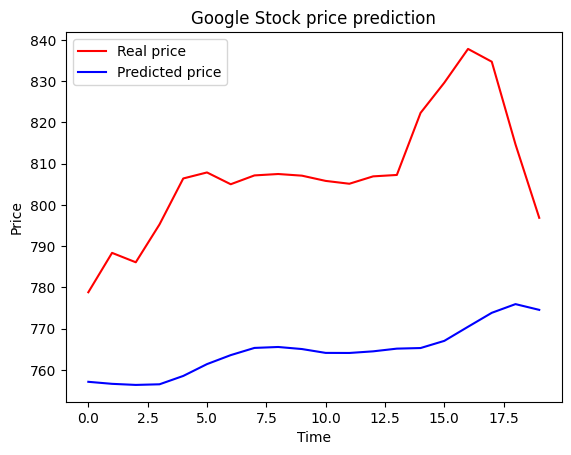

In [ ]:

plt.plot(y_test, color = 'red', label = 'Real price')
plt.plot(y_pred, color = 'blue', label = 'Predicted price')

plt.title('Google Stock price prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

DL_mini_project

In [ ]:
!pip install deepface opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.7 MB/s eta 0:00:00


26-04-25 09:23:05 - Directory /root/.deepface has been created
26-04-25 09:23:05 - Directory /root/.deepface/weights has been created


Saving man1.jpg to man1.jpg


Action: age:   0%|          | 0/2 [00:00<?, ?it/s]    

26-04-25 09:23:20 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5

  0%|          | 0.00/539M [00:00<?, ?B/s]
  2%|▏         | 11.0M/539M [00:00<00:12, 42.3MB/s]
  4%|▍         | 21.5M/539M [00:00<00:12, 40.9MB/s]
  6%|▌         | 32.0M/539M [00:00<00:12, 42.1MB/s]
  8%|▊         | 42.5M/539M [00:01<00:12, 41.0MB/s]
 10%|▉         | 53.0M/539M [00:01<00:11, 42.4MB/s]
 12%|█▏        | 63.4M/539M [00:01<00:11, 42.4MB/s]
 14%|█▎        | 73.9M/539M [00:01<00:11, 42.1MB/s]
 16%|█▌        | 84.4M/539M [00:02<00:10, 41.6MB/s]
 18%|█▊        | 94.9M/539M [00:02<00:17, 25.9MB/s]
 20%|█▉        | 105M/539M [00:03<00:14, 29.5MB/s] 
 22%|██▏       | 116M/539M [00:03<00:13, 32.4MB/s]
 23%|██▎       | 126M/539M [00:03<00:11, 35.4MB/s]
 25%|██▌       | 137M/539M [00:03<00:10, 36.9MB/s]
 27%|██▋       | 147M/539M [00:03<00:10, 38.3MB/s]
 29%|██▉       | 158M/539M [00:04<00:15, 25.2MB/s]
 31%|███       | 168M/5

26-04-25 09:23:39 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  9%|▊         | 46.7M/537M [00:00<00:01, 465MB/s]
 17%|█▋        | 93.8M/537M [00:00<00:00, 467MB/s]
 26%|██▋       | 141M/537M [00:00<00:00, 448MB/s] 
 35%|███▍      | 186M/537M [00:00<00:00, 413MB/s]
 42%|████▏     | 228M/537M [00:00<00:00, 398MB/s]
 51%|█████     | 272M/537M [00:00<00:00, 408MB/s]
 58%|█████▊    | 313M/537M [00:00<00:00, 406MB/s]
 66%|██████▋   | 357M/537M [00:00<00:00, 414MB/s]
 74%|███████▍  | 398M/537M [00:01<00:00, 348MB/s]
 81%|████████  | 435M/537M [00:01<00:00, 323MB/s]
 87%|████████▋ | 469M/537M [00:01<00:00, 317MB/s]
100%|██████████| 537M/537M [00:01<00:00, 372MB/s]
Action: gender: 100%|██████████| 2/2 [00:23<00:00, 11.86s/it]


Detected Age: 35
Detected Gender: Man


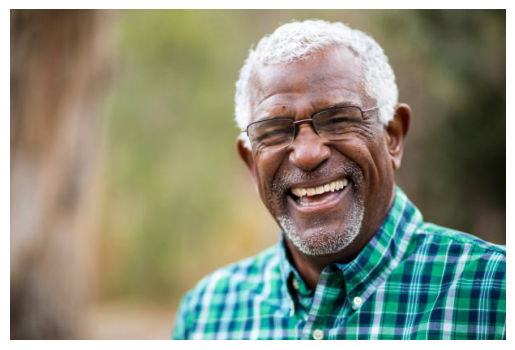

In [ ]:
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

# -------------------------------
# Module 1: Input
# -------------------------------
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# -------------------------------
# Module 2: Face Detection
# -------------------------------
def detect_faces(image):
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    return faces

# -------------------------------
# Module 3: Prediction
# -------------------------------
def predict_age_gender(img_path):
    results = DeepFace.analyze(
    img_path,
    actions=['age', 'gender'],
    enforce_detection=False
    )
    return results[0]

# -------------------------------
# Module 4: Output
# -------------------------------
def display_result(image, faces, prediction):
    age = prediction['age']
    gender = prediction['dominant_gender']

    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(image, f"{gender}, {age}", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

# -------------------------------
# MAIN EXECUTION
# -------------------------------
image = cv2.imread(img_path)

faces = detect_faces(image)
prediction = predict_age_gender(img_path)

display_result(image, faces, prediction)
print("Detected Age:", prediction['age'])
print("Detected Gender:", prediction['dominant_gender'])